# **PCA and LDA on Students' Dropout and Academic Success Rate Dataset**
## AI 221 Assignment 06

Submitted by: **Pangilinan, Reignel Bernice** 2018-01460


Dataset reference:
Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict Students' Dropout and Academic Success [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89.




Code is based on Dr. K. Pilario's work in https://github.com/kspilario/AI221/blob/main/Linear_DimReduce%2BLDA/pca_svm_lda_iris.ipynb

In [ ]:
!pip install ucimlrepo

In [ ]:
import numpy as np    # Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV

import time

from ucimlrepo import fetch_ucirepo   # Dataset is from UCI ML repository, packaged for easier import to Python

# Fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id = 697)

X = predict_students_dropout_and_academic_success.data.features   # Features as pandas dataframe
y = predict_students_dropout_and_academic_success.data.targets    # Labels as pandas column

print("========== DATASET VARIABLES ==========")
print(predict_students_dropout_and_academic_success.variables)    # Display information on the dataset

data = pd.concat([X, y], axis = 1)   # Combine features and labels into a single dataframe
print("========== DATASET ==========")
display(data.head(10))   # Display the first few rows of the dataset
print(f"There are {data.shape[1]} features and {data.shape[0]} instances within the dataset.")

========== DATASET VARIABLES ==========
                                              name     role         type  \
0                                   Marital Status  Feature      Integer   
1                                 Application mode  Feature      Integer   
2                                Application order  Feature      Integer   
3                                           Course  Feature      Integer   
4                       Daytime/evening attendance  Feature      Integer   
5                           Previous qualification  Feature      Integer   
6                   Previous qualification (grade)  Feature   Continuous   
7                                      Nacionality  Feature      Integer   
8                           Mother's qualification  Feature      Integer   
9                           Father's qualification  Feature      Integer   
10                             Mother's occupation  Feature      Integer   
11                             Father's occupati

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


There are 37 features and 4424 instances within the dataset.


## **Expoloratory Data Analysis (EDA)**

There are 37 features and 4,424 samples within the dataset which makes creating correlograms impractical especially since most of the columns are categorical. Here, we instead displayed the correlation matrix to give us an idea which features are highly correlated with each other.  

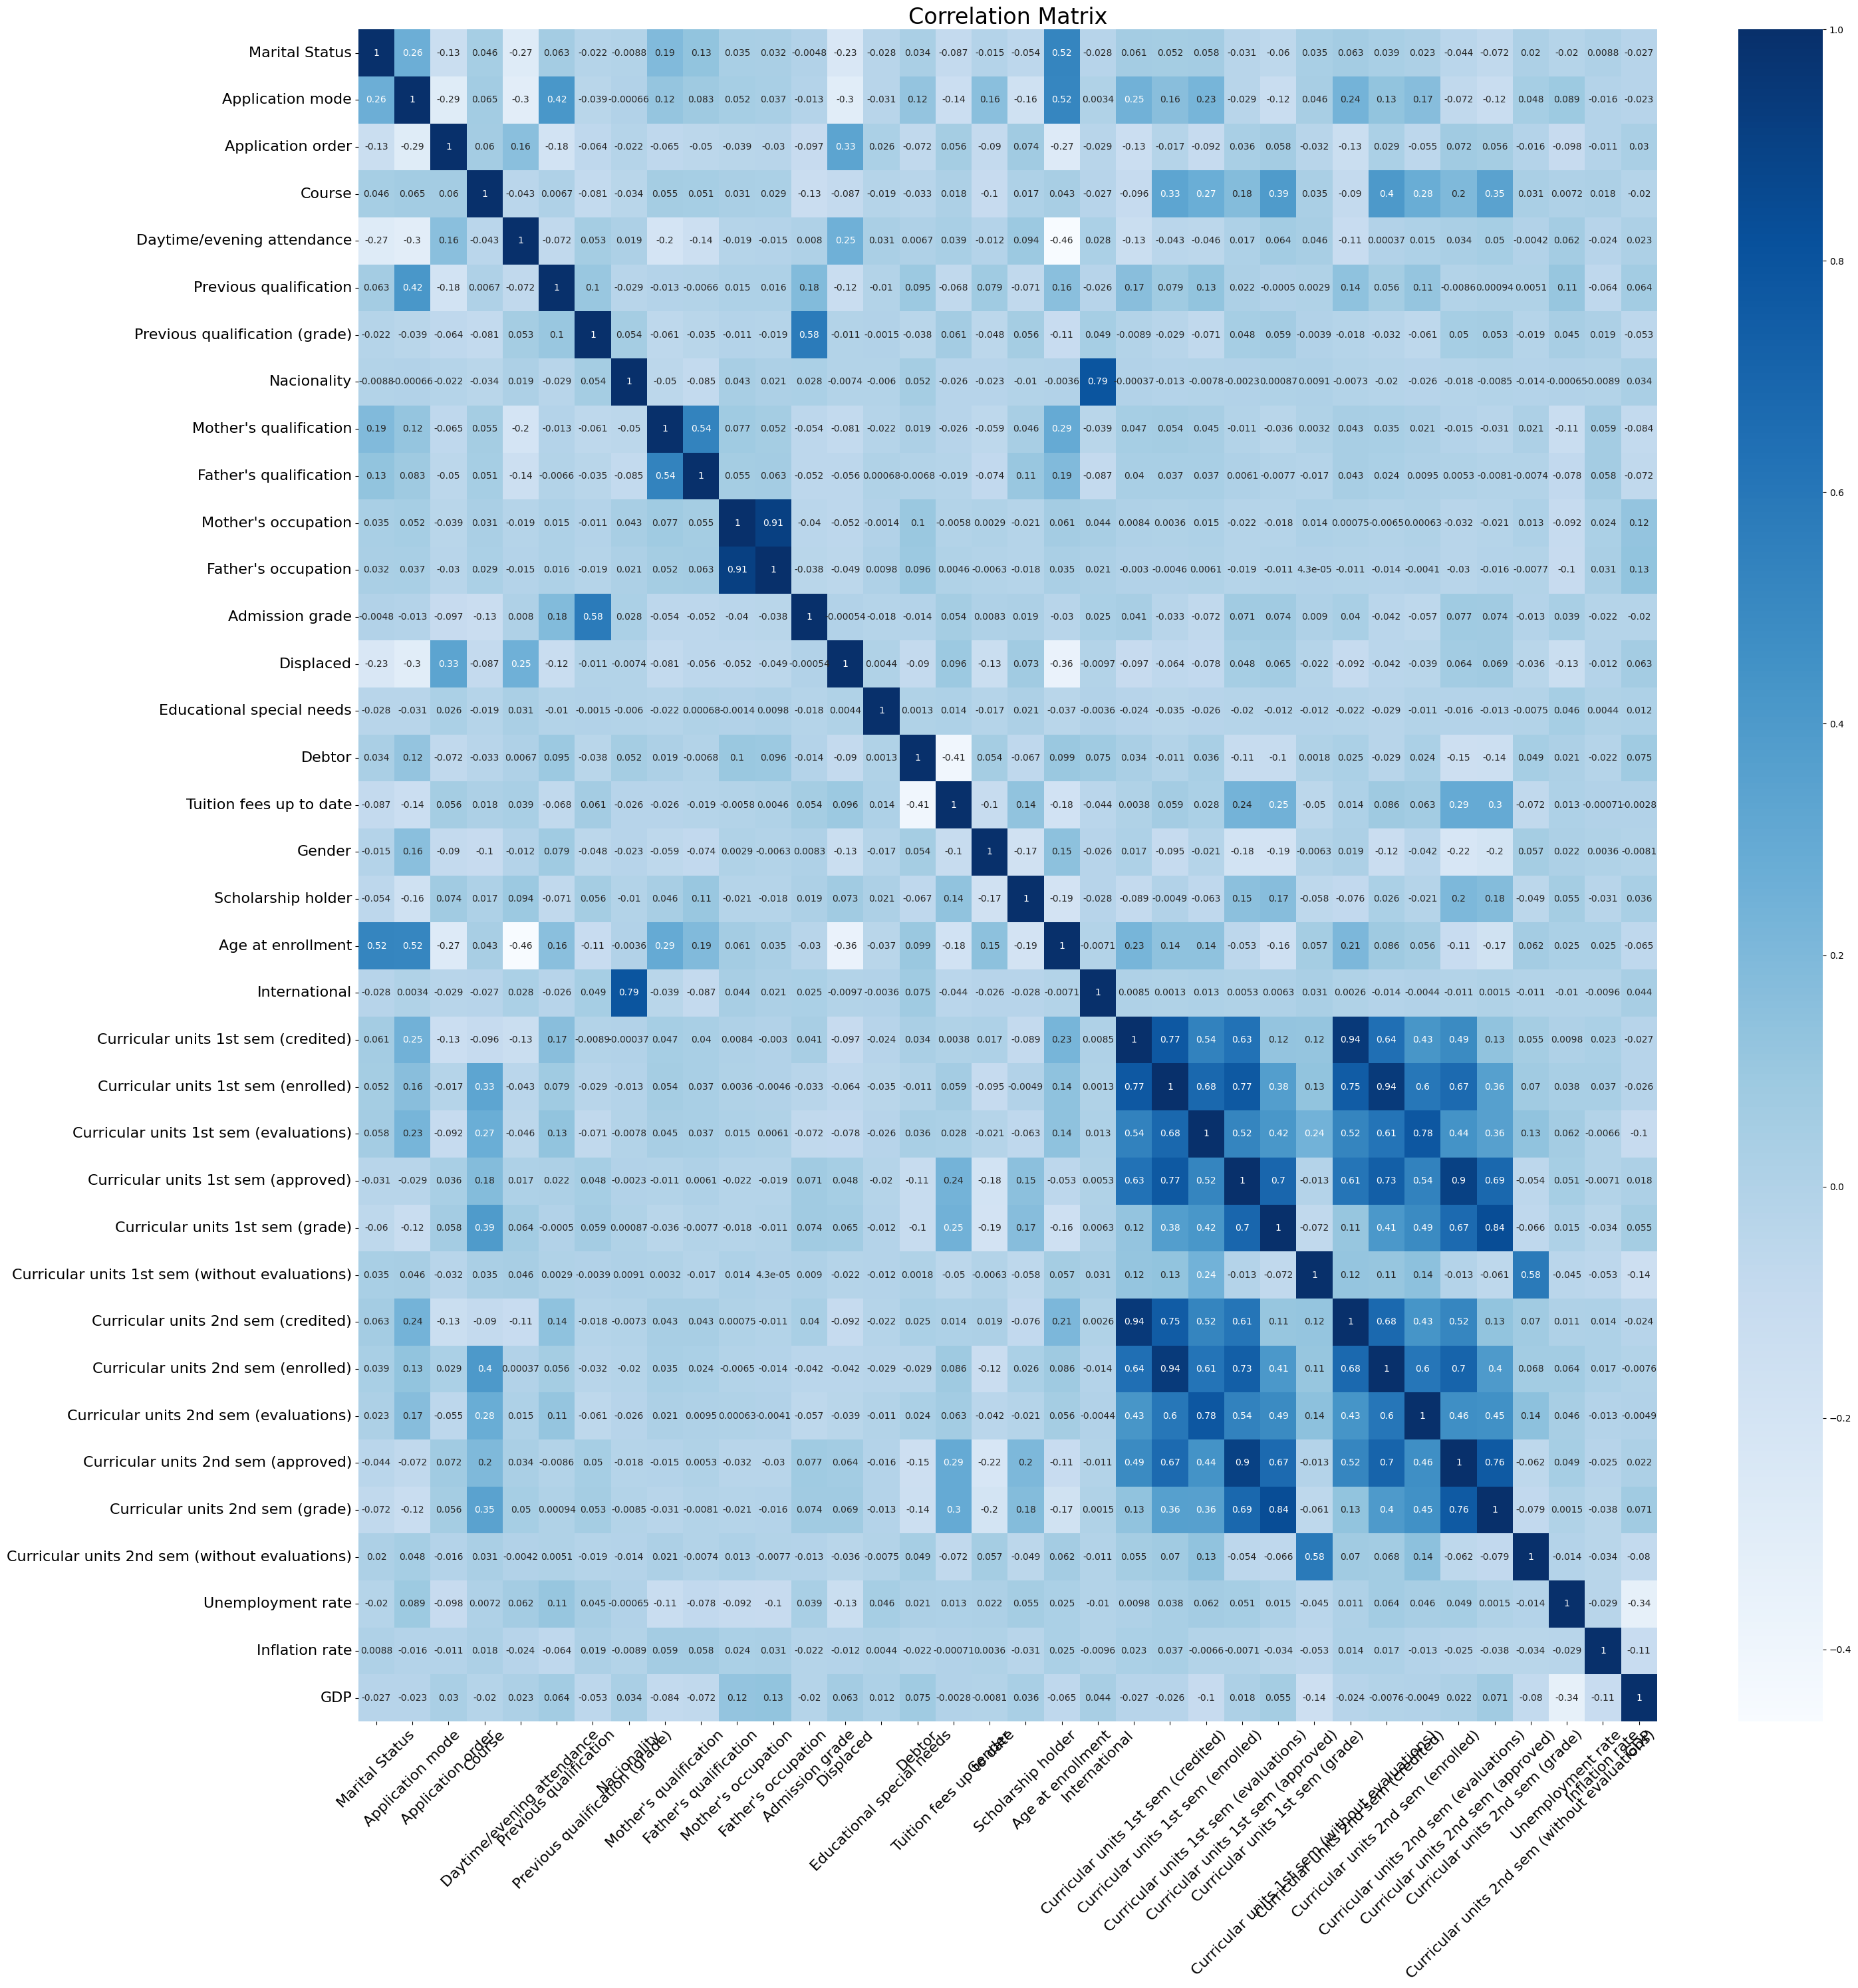

In [ ]:
# Create paiprlots of the features in the dataset
#plt.figure(figsize = (8, 8))   # Initialize the figure size
#sns.pairplot(data, hue = "Target")   # Use seaborn to plot multiple pairwise distributions within data (note: use data not scaled here)
#sns.color_palette("ch:start=.2,rot=-.3", as_cmap = True)    # Set the color palette for the pairplots
#plt.title("Correlogram")   # Add a title
#plt.tight_layout()    # Adjust the layout
#plt.show()    # Display the plot, diagonal contains the univariate plots

# Create a correlation matrix to better interpret the pairplots
plt.figure(figsize = (30, 30))   # Initialize the figure size
corr_matrix = data.iloc[:, :X.shape[1]].corr()  # Compute for the correlation matrix
sns.heatmap(corr_matrix, annot = True, annot_kws = {"size": 10}, cmap = plt.cm.Blues)    # Use seaborn to plot a heatmap of the correlation matrix
plt.title("Correlation Matrix", fontsize = 24)   # Add a title
plt.yticks(fontsize = 16)   # Custmoize the text of the y-ticks
plt.xticks(rotation = 45, fontsize = 16)   # Customize the text of the x-ticks
plt.tight_layout()    # Adjust the layout
plt.show()    # Display the plot

Setting the threshold for high correlation as **0.70** (both for positive and negative correlation), we can filter out the features with high correlation. By creating scatterplots of the features with high correlation, we see that indeed, these features has a clear positive (or negative) relationship.

Highly-correlated features:
Nacionality and International: 0.79


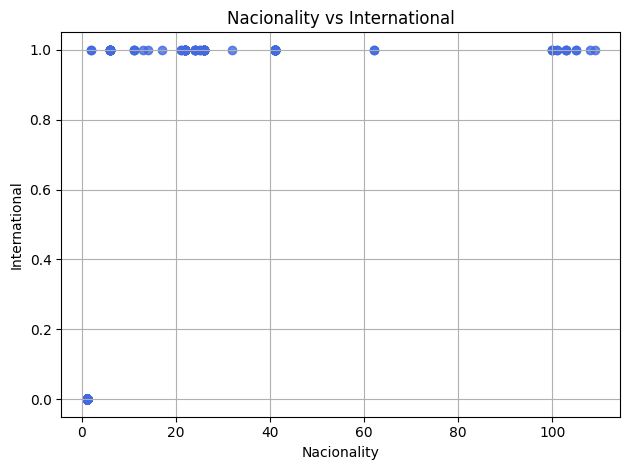

Mother's occupation and Father's occupation: 0.91


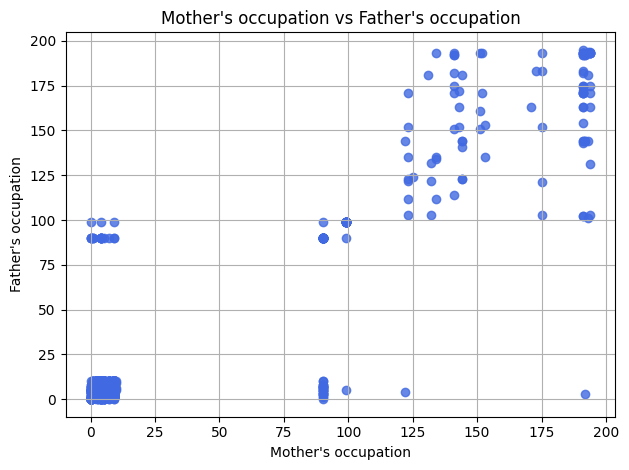

Curricular units 1st sem (credited) and Curricular units 1st sem (enrolled): 0.77


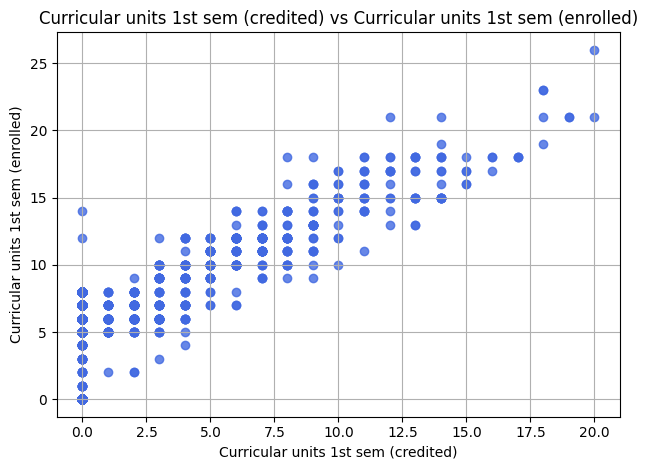

Curricular units 1st sem (credited) and Curricular units 2nd sem (credited): 0.94


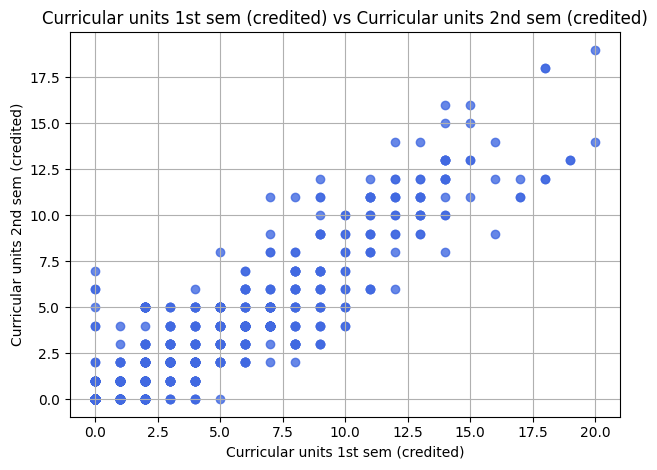

Curricular units 1st sem (enrolled) and Curricular units 1st sem (approved): 0.77


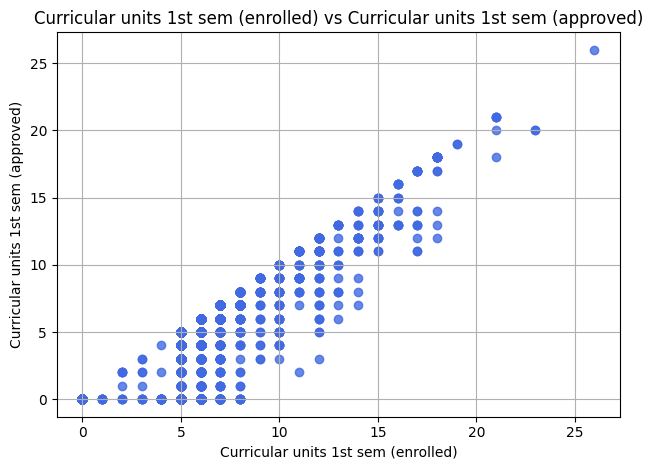

Curricular units 1st sem (enrolled) and Curricular units 2nd sem (credited): 0.75


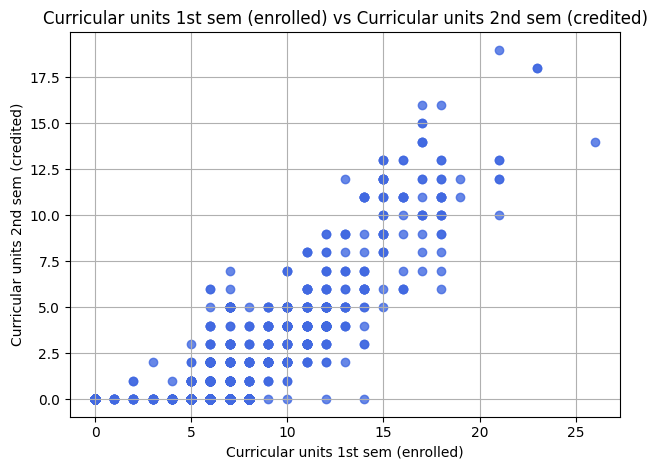

Curricular units 1st sem (enrolled) and Curricular units 2nd sem (enrolled): 0.94


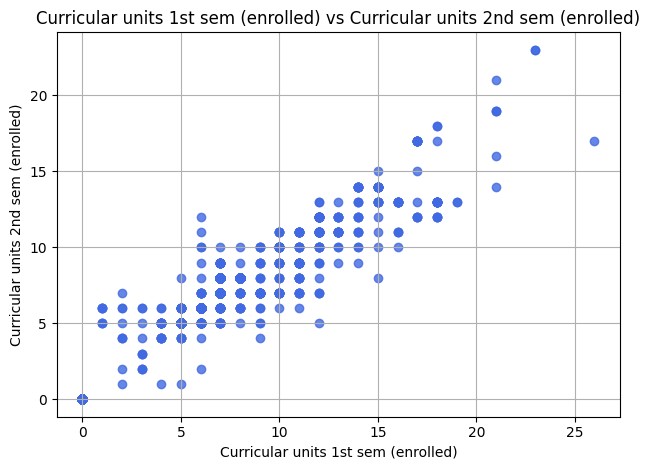

Curricular units 1st sem (evaluations) and Curricular units 2nd sem (evaluations): 0.78


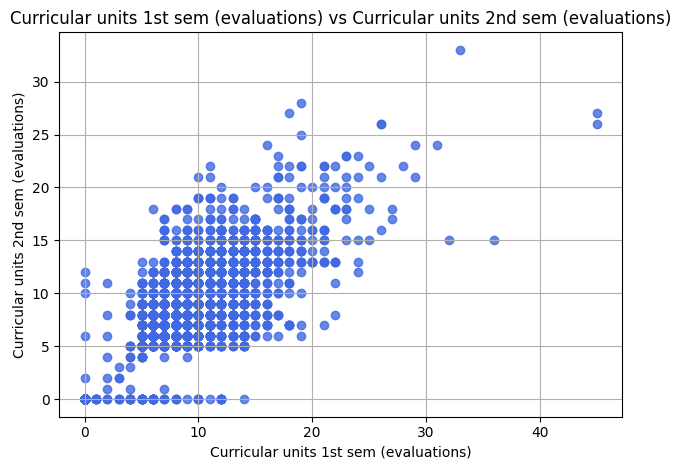

Curricular units 1st sem (approved) and Curricular units 2nd sem (enrolled): 0.73


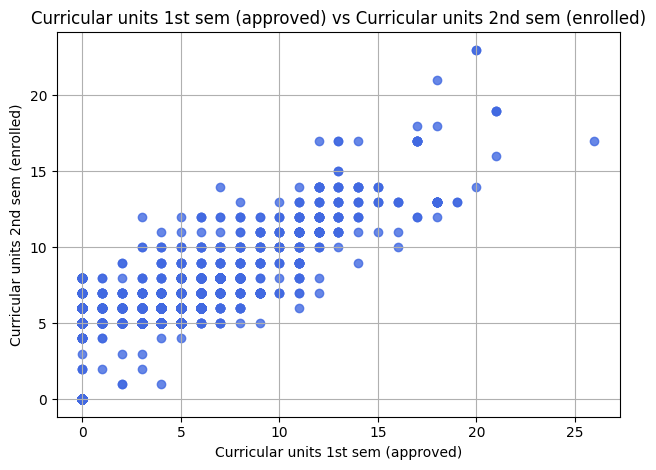

Curricular units 1st sem (approved) and Curricular units 2nd sem (approved): 0.90


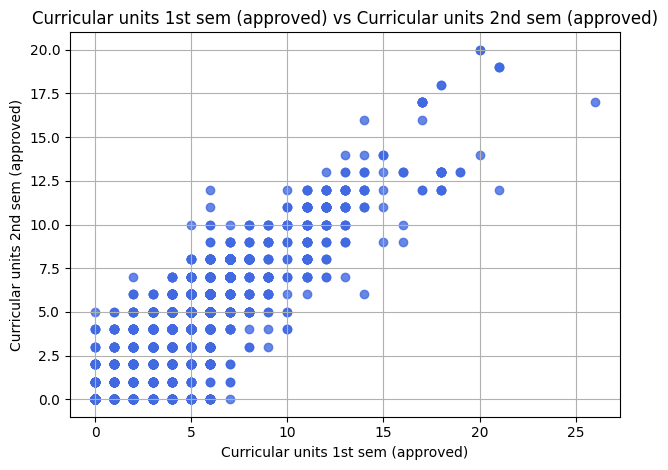

Curricular units 1st sem (grade) and Curricular units 2nd sem (grade): 0.84


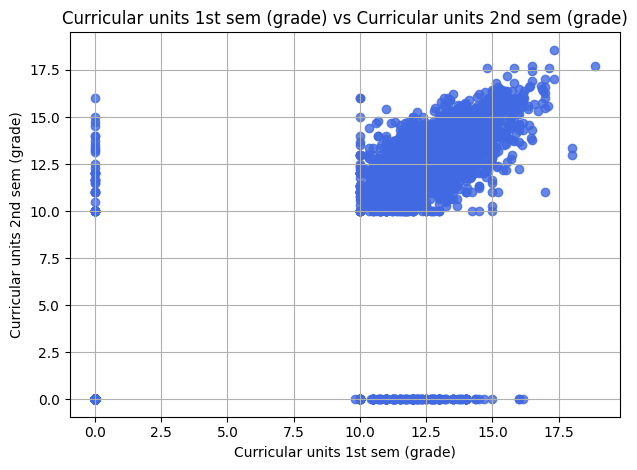

Curricular units 2nd sem (enrolled) and Curricular units 2nd sem (approved): 0.70


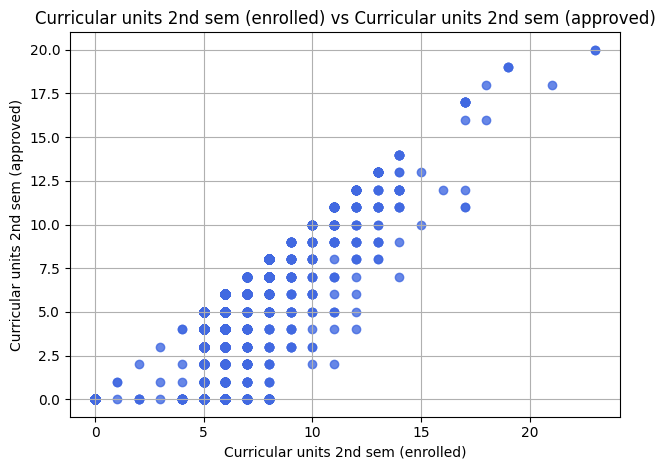

Curricular units 2nd sem (approved) and Curricular units 2nd sem (grade): 0.76


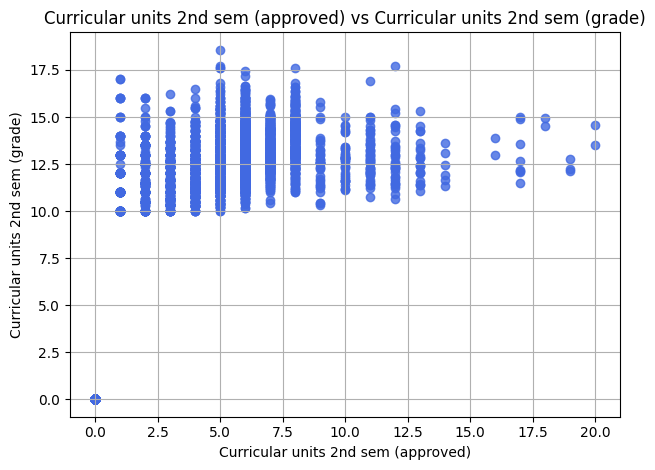

In [ ]:
# Filter the features with high correlation
threshold_pos = 0.70    # Set the threshold of the correlation value, strong positive or strong negative correlation
threshold_neg = -0.70

highly_correlated_features = []   # Initialize an empty list of highly-correlated features
for i in range(len(corr_matrix.columns)):   # Iterate over each value in the correlation matrix
  for j in range(i + 1, len(corr_matrix.columns)):
    if corr_matrix.iloc[i, j] > threshold_pos or corr_matrix.iloc[i, j] < threshold_neg:    # Append these to the list if value is beyond the threshold
      highly_correlated_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if not highly_correlated_features:    # If there are no highly-correlated values, print this
  print("No highly-correlated features found.")

else:
  print("Highly-correlated features:")    # Print and plot the features with high correlation
  for feature1, feature2, correlation in highly_correlated_features:
    print(f"{feature1} and {feature2}: {correlation:.2f}")
    plt.scatter(data[feature1], data[feature2], color = "royalblue", alpha = 0.8) # Create a scatterplot of feature1 v. feature2 for visualization
    plt.xlabel(f"{feature1}")
    plt.ylabel(f"{feature2}")
    plt.title(f"{feature1} vs {feature2}")
    plt.grid()
    plt.tight_layout()
    plt.show()


The features, or column names in this case, are stored in a single list so that columns with high correlation may be dropped (should it be needed in classification).

In [ ]:
# Get the features with high correlation
column_names = []   # Initialize empty list of column names of highly-correlated features
for feature1, feature2, correlation in highly_correlated_features:
  column_names.append(feature1)   # Add them to the empty list
  column_names.append(feature2)

column_names = list(set(column_names))   # Remove duplicates
print("Features with high correlation:")    # Display the list of features with high correlation
for column in column_names:
  print(column)

Features with high correlation:
Curricular units 1st sem (approved)
Curricular units 1st sem (credited)
Curricular units 2nd sem (credited)
Curricular units 1st sem (enrolled)
Nacionality
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (grade)
Curricular units 1st sem (evaluations)
Father's occupation
Curricular units 1st sem (grade)
Curricular units 2nd sem (approved)
International
Curricular units 2nd sem (evaluations)
Mother's occupation


Moreover, to check for class imbalance, we can get the frequency of each class and visualize them as bar graphs. We see that there are more instances of the class "Graduate", followed by "Dropout" and then finally, the least number is "Enrolled".

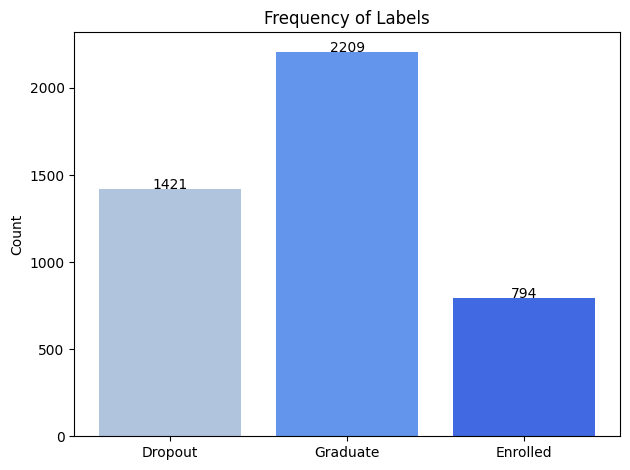

In [ ]:
# Check to see if there are any imbalances within the data
from collections import Counter

freq_labels = Counter(y.values.ravel())   # Get the frequency of each label
labels = list(freq_labels.keys())
freq = list(freq_labels.values())

plt.bar(labels, freq, color = ["lightsteelblue", "cornflowerblue", "royalblue"])   # Create a barplot of the frequency of each label
for i in range(len(freq)):    # Insert the frequencies in the bar graph
  plt.text(labels[i], freq[i], freq[i], ha = "center")
plt.ylabel("Count")
plt.title("Frequency of Labels")
plt.tight_layout()
plt.show()

There appears to be class imbalance within the data which might affect the results when classification is performed. We may apply Synthetic Minority Over-sampling Technique (SMOTE) to deal with the class imbalance (just to be safe).  

========== DATASET AFTER SMOTE ==========


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.000000,1,19,12,...,0,0,0,0,0.000000,0,10.800000,1.400000,1.740000,Dropout
1,1,15,1,9254,1,1,160.000000,1,1,3,...,0,6,6,6,13.666667,0,13.900000,-0.300000,0.790000,Graduate
2,1,1,5,9070,1,1,122.000000,1,37,37,...,0,6,0,0,0.000000,0,10.800000,1.400000,1.740000,Dropout
3,1,17,2,9773,1,1,122.000000,1,38,37,...,0,6,10,5,12.400000,0,9.400000,-0.800000,-3.120000,Graduate
4,2,39,1,8014,0,1,100.000000,1,37,38,...,0,6,6,6,13.000000,0,13.900000,-0.300000,0.790000,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6622,1,1,1,9853,1,1,127.572544,1,4,1,...,0,6,9,4,12.705014,0,10.800000,1.400000,1.740000,Enrolled
6623,1,17,4,9500,1,1,136.446258,1,1,1,...,0,8,8,7,12.775719,0,13.556680,-0.111728,0.895211,Enrolled
6624,1,1,1,9147,1,1,129.240418,1,37,37,...,0,5,9,3,13.250375,0,10.030664,1.688501,1.398607,Enrolled
6625,2,39,1,9991,0,39,140.000000,1,37,19,...,0,5,7,5,11.808354,0,12.660616,3.646295,-1.716947,Enrolled


Dimensions of the dataset afer SMOTE: (6627, 36)


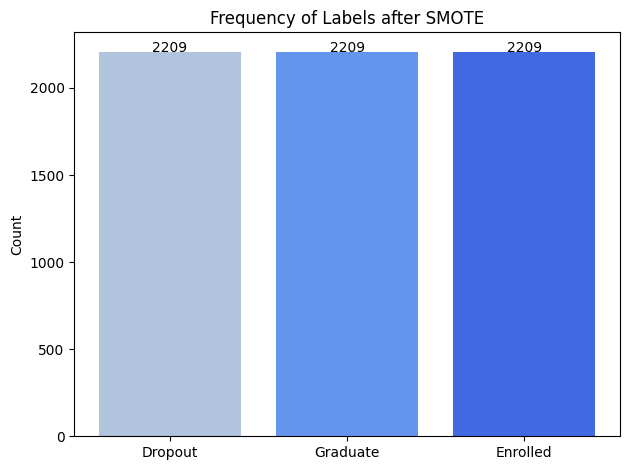

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)    # Use SMOTE to balance the classes
X_smote, y_smote = smote.fit_resample(X, y)
X, y = X_smote, y_smote

print("========== DATASET AFTER SMOTE ==========")
display(pd.concat((X, y), axis = 1))
print(f"Dimensions of the dataset afer SMOTE: {X.shape}")

freq_labels = Counter(y.values.ravel())   # Get the frequency of each label
labels = list(freq_labels.keys())
freq = list(freq_labels.values())

plt.bar(labels, freq, color = ["lightsteelblue", "cornflowerblue", "royalblue"])   # Create a barplot of the frequency of each label
for i in range(len(freq)):    # Insert the frequencies in the bar graph
  plt.text(labels[i], freq[i], freq[i], ha = "center")
plt.ylabel("Count")
plt.title("Frequency of Labels after SMOTE")
plt.tight_layout()
plt.show()

## **Classification without Dimensionality Reduction**

Two models, logistic regression and SVM, are used for classification in the function *Classify*. The hyperparameters of these models are tuned obtaining their cross-validation scores. The performance of these two are compared to determine which model works best for the given dataset.

In [ ]:
def Classify(X_train, X_test, y_train, y_test):
  """
    Function that performs Logistic Regression and SVM classification on the dataset.
    This also includes hyperparameter tuning and cross-validation.
    Classification report and confusion matrix will be generated and displayed for each classifier.
    Inputs: X_train, training set (scaled)
            X_test, test set (scaled)
            y_train, training labels (encoded)
            y_test, test labels (encoded)
    Outputs: None
  """
  # Encode the labels
  encoder = LabelEncoder()
  y_train = encoder.fit_transform(y_train.values.ravel())
  y_test = encoder.fit_transform(y_test.values.ravel())

  # Define the models and hyperparameters to tune
  # Create a dictionary of the classifiers
  models = {"Logistic Regression": LogisticRegression(max_iter = 1000), "SVM": SVC()}

  # Define parameter grids for each model
  # Create a dictionary of the hyperparamters to tune for each model
  param_grids = {"Logistic Regression": {"C": [0.1, 1, 10, 100, 1000], "solver":["lbfgs", "liblinear", "saga"]},
               "SVM": {"C": [1, 10, 100, 1000], "gamma": [1, 0.1, 0.01, 0.001], "kernel": ["rbf"]}}

  # Perform GridSearchCV for each model
  # Create a dictionary to store the best parameters for each model
  best_models = {}

  for model_name, model in models.items():
    # Display progress
    print(f"Training {model_name} with GridSearchCV...")
    # Perform GridSearchCV
    grid_search = GridSearchCV(model, param_grids[model_name], cv = 5, n_jobs = -1)  # 5-fold cross-validation
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_   # Store the best estimator with the best parameters
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.2f}\n")

  # Evaluate models with best parameters on test data using all classifiers
  accuracy_scores = []    # Initialize a list of accuracy scores and computing time
  computing_time = []
  for model_name, best_model in best_models.items():
    # Measure computation time of each model
    start = time.time()
    y_pred = best_model.predict(X_test)
    end = time.time()

    print(f"Classification results using {model_name}:")
    print(f"Test accuracy of {model_name}: {accuracy_score(y_test, y_pred):.2f}")  # Print accuracy
    print(f"Computation time: {(end - start):.4f} s")  # Print the computation time
    print(classification_report(y_test, y_pred))  # Print the classification report

    accuracy_scores.append(np.round(accuracy_score(y_test, y_pred), 2))    # Append accuracy scores and computing times for comparison
    computing_time.append(np.round(end - start, 4))

    # Print the confusion matrix per classifier results
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels = list(np.unique(encoder.inverse_transform(y_test)))).plot(cmap = plt.cm.Blues, colorbar = False)
    plt.title(f"Confusion Matrix using {model_name}")
    plt.tight_layout()
    plt.show()

  # Create bar graphs for comparing the accuracy and computing time of the two models
  model_names = list(models.keys())
  plt.figure(figsize = (10, 5))

  plt.subplot(1, 2, 1)
  plt.bar(model_names, accuracy_scores, color = ["royalblue", "cornflowerblue"])
  for i in range(len(model_names)):    # Insert the frequencies in the bar graph
    plt.text(model_names[i], accuracy_scores[i], accuracy_scores[i], ha = "center")
  plt.ylabel("Accuracy")
  plt.title("Classification Accuracy")

  plt.subplot(1, 2, 2)
  plt.bar(model_names, computing_time, color = ["royalblue", "cornflowerblue"])
  for i in range(len(model_names)):    # Insert the frequencies in the bar graph
    plt.text(model_names[i], computing_time[i], computing_time[i], ha = "center")
  plt.ylabel("Computing Time (s)")
  plt.title("Computing Time")

  plt.tight_layout()
  plt.show()

========== Classification on entire dataset ==========
Training Logistic Regression with GridSearchCV...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Best cross-validation score: 0.76

Training SVM with GridSearchCV...
Best parameters for SVM: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.77

Classification results using Logistic Regression:
Test accuracy of Logistic Regression: 0.76
Computation time: 0.0010 s
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       427
           1       0.55      0.28      0.37       238
           2       0.78      0.94      0.85       663

    accuracy                           0.76      1328
   macro avg       0.71      0.66      0.67      1328
weighted avg       0.74      0.76      0.74      1328



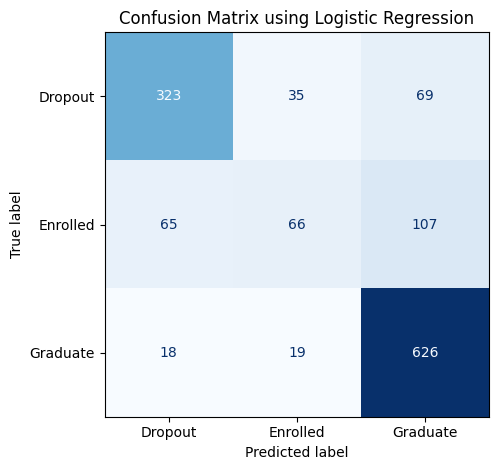

Classification results using SVM:
Test accuracy of SVM: 0.77
Computation time: 0.1562 s
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       427
           1       0.55      0.39      0.46       238
           2       0.80      0.94      0.86       663

    accuracy                           0.77      1328
   macro avg       0.73      0.69      0.70      1328
weighted avg       0.76      0.77      0.76      1328



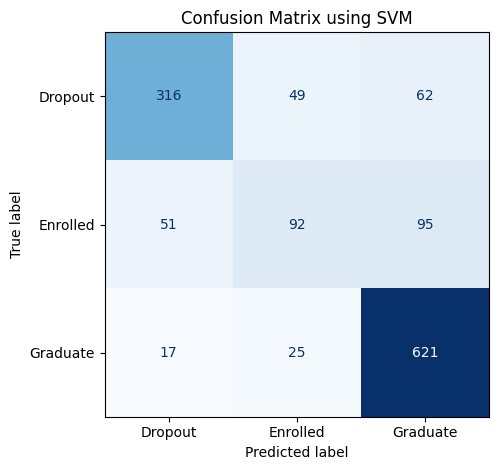

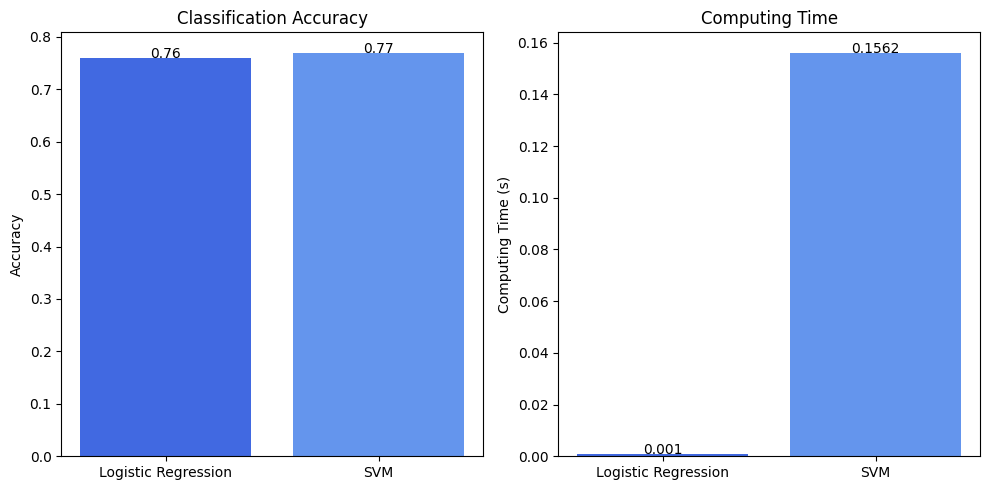

In [ ]:
### Do classification on the entire dataset with highly-correlated
X = data.iloc[:, :data.shape[1] - 1]
y = data["Target"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, stratify = y, random_state = 42)   # Do a 70-30 split

print("========== Classification on entire dataset ==========")
Classify(X_train, X_test, y_train, y_test)

========== Classification without highly-correlated features ==========
Training Logistic Regression with GridSearchCV...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Best cross-validation score: 0.62

Training SVM with GridSearchCV...
Best parameters for SVM: {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.63

Classification results using Logistic Regression:
Test accuracy of Logistic Regression: 0.62
Computation time: 0.0010 s
              precision    recall  f1-score   support

           0       0.63      0.56      0.60       427
           1       0.25      0.01      0.02       238
           2       0.63      0.88      0.73       663

    accuracy                           0.62      1328
   macro avg       0.50      0.49      0.45      1328
weighted avg       0.56      0.62      0.56      1328



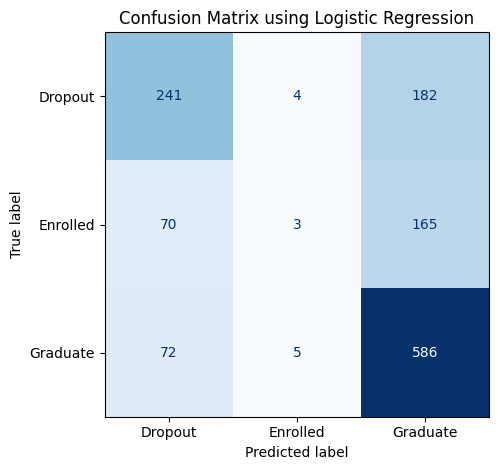

Classification results using SVM:
Test accuracy of SVM: 0.62
Computation time: 0.1925 s
              precision    recall  f1-score   support

           0       0.63      0.56      0.60       427
           1       0.46      0.08      0.13       238
           2       0.62      0.86      0.72       663

    accuracy                           0.62      1328
   macro avg       0.57      0.50      0.48      1328
weighted avg       0.60      0.62      0.58      1328



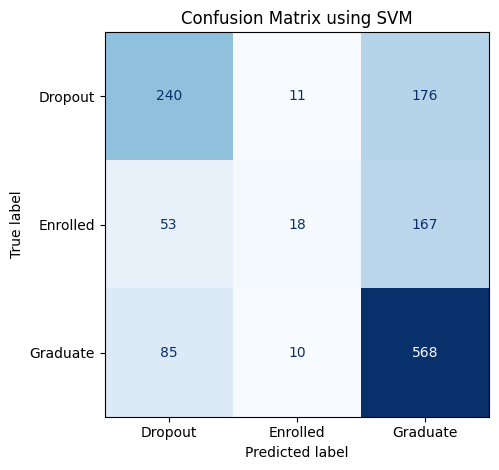

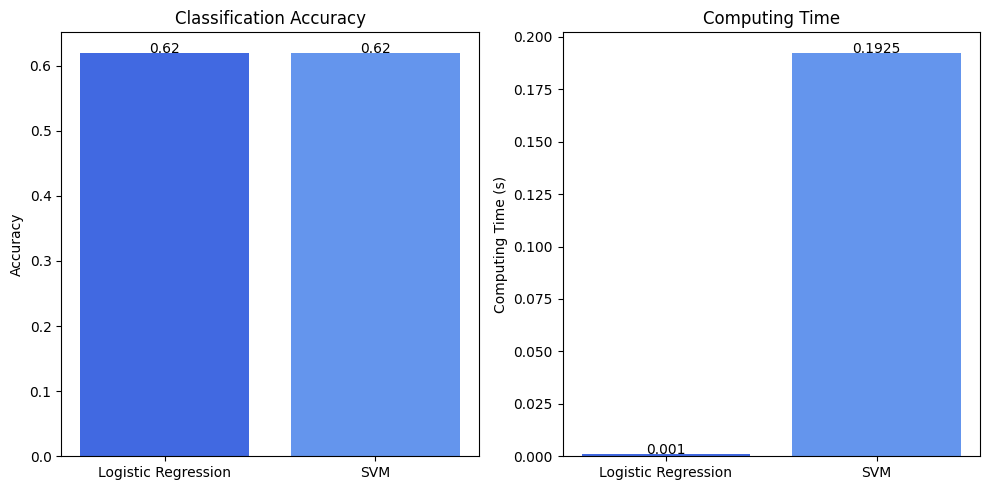

In [ ]:
### Do classification on the dataset with highly-correlated features dropped
# Filter the data by dropping the columns with highly-correlated features
data_filtered = data.drop(columns = column_names)
X_filtered = data_filtered.iloc[:, :data_filtered.shape[1] - 1]
y_filtered = data_filtered.iloc[:, data_filtered.shape[1] - 1]

# Scale the features
scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)

# Split the data into training and test sets
X_filtered_train, X_filtered_test, y_filtered_train, y_filtered_test = train_test_split(X_filtered_scaled, y_filtered, test_size = 0.3, stratify = y, random_state = 42)   # Do a 70-30 split

print("========== Classification without highly-correlated features ==========")
Classify(X_filtered_train, X_filtered_test, y_filtered_train, y_filtered_test)

## **Principal Component Analysis (PCA)**

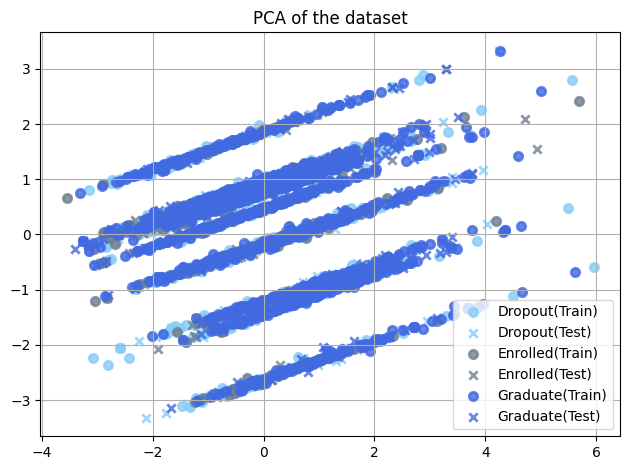

========== Classification on new feature space after PCA ==========
Training Logistic Regression with GridSearchCV...
Best parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}
Best cross-validation score: 0.51

Training SVM with GridSearchCV...
Best parameters for SVM: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.51

Classification results using Logistic Regression:
Test accuracy of Logistic Regression: 0.50
Computation time: 0.0009 s
              precision    recall  f1-score   support

           0       0.42      0.07      0.13       427
           1       0.00      0.00      0.00       238
           2       0.51      0.96      0.66       663

    accuracy                           0.50      1328
   macro avg       0.31      0.34      0.26      1328
weighted avg       0.39      0.50      0.37      1328



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


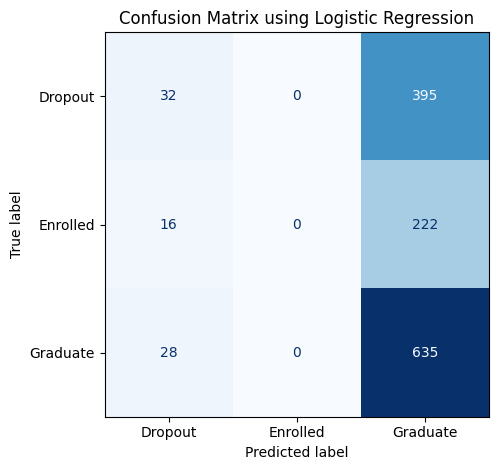

Classification results using SVM:
Test accuracy of SVM: 0.51
Computation time: 0.2075 s
              precision    recall  f1-score   support

           0       0.54      0.07      0.13       427
           1       0.00      0.00      0.00       238
           2       0.51      0.97      0.67       663

    accuracy                           0.51      1328
   macro avg       0.35      0.35      0.27      1328
weighted avg       0.43      0.51      0.37      1328



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


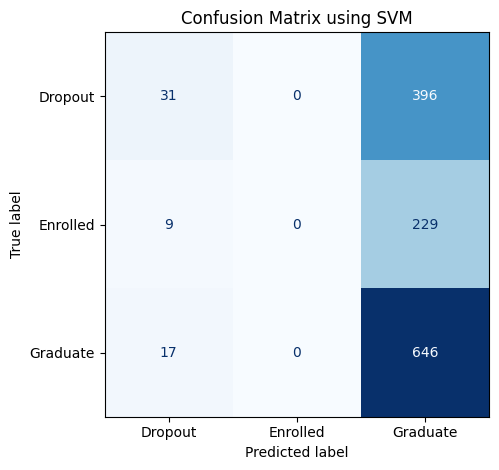

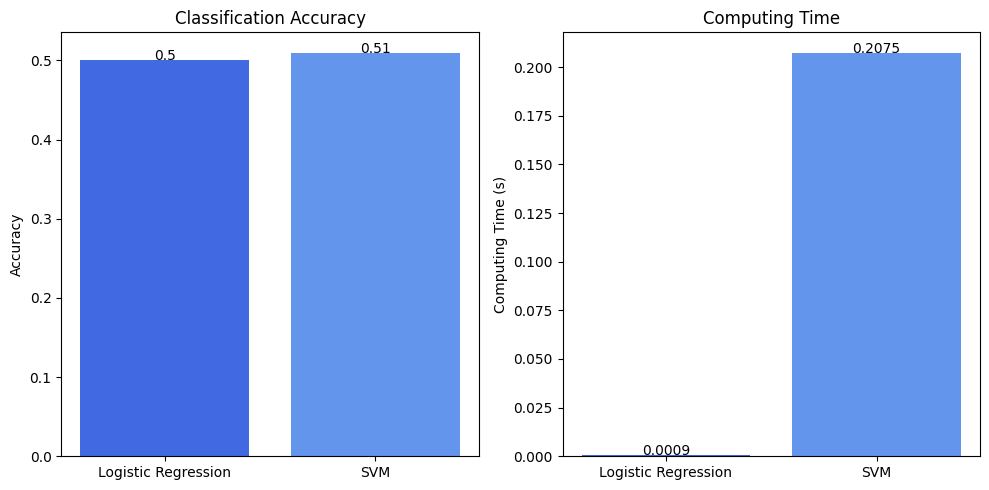

In [ ]:
from sklearn.decomposition import PCA

# Get the features that are not categorical, these are the features that are continuous according to the dataset variables report
X = data[["Previous qualification (grade)", "Admission grade", "Unemployment rate", "Inflation rate", "GDP"]]
y = data["Target"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, stratify = y, random_state = 42)   # Do a 70-30 split

# Perform PCA
pca = PCA(n_components = 2)   # Perform PCA, obtain 2 components
X_train_pca = pca.fit_transform(X_train, y_train)
X_test_pca = pca.transform(X_test)

# Encode the labels
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train.values.ravel())
y_test_encoded = encoder.fit_transform(y_test.values.ravel())

# Create scatterplot of PCA results
targets = list(np.unique(y))
colors = ["lightskyblue", "slategrey", "royalblue"]
for color, i, target_name in zip(colors, [0, 1, 2], targets):   # Plot the principal components of the training and test sets as a scatterplot
  plt.scatter(X_train_pca[y_train_encoded == i, 0], X_train_pca[y_train_encoded == i, 1], color = color, alpha = 0.8, lw = 2, label = target_name + "(Train)")
  plt.scatter(X_test_pca[y_test_encoded == i, 0], X_test_pca[y_test_encoded == i, 1], color = color, alpha = 0.8, lw = 2, label = target_name + "(Test)", marker = "x")

plt.legend(loc = "best", shadow = False)    # Add a legend
plt.title("PCA of the dataset")
plt.tight_layout()
plt.grid()
plt.show()

### Do classification on the principal components after PCA
print("========== Classification on new feature space after PCA ==========")
Classify(X_train_pca, X_test_pca, y_train, y_test)    # Use the function "Classify" from the previous section

## **Linear Discriminant Analysis (LDA)**

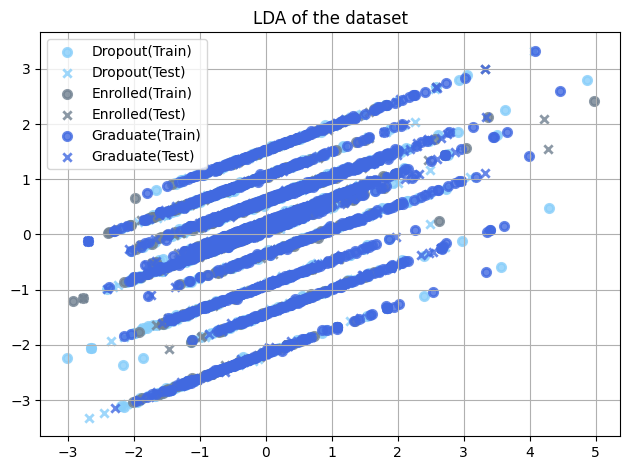

========== Accuracy of LDA on training and testing data ==========
Training accuracy: 0.51
Testing accuracy: 0.50
              precision    recall  f1-score   support

     Dropout       0.41      0.09      0.15       427
    Enrolled       0.00      0.00      0.00       238
    Graduate       0.51      0.94      0.66       663

    accuracy                           0.50      1328
   macro avg       0.30      0.34      0.27      1328
weighted avg       0.38      0.50      0.38      1328



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


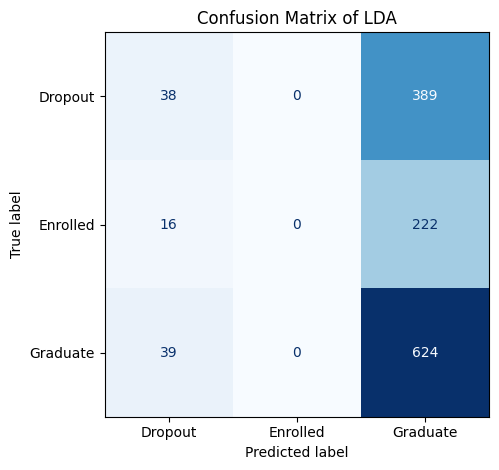

========== Classification on new feature space after LDA ==========
Training Logistic Regression with GridSearchCV...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Best cross-validation score: 0.51

Training SVM with GridSearchCV...
Best parameters for SVM: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validation score: 0.52

Classification results using Logistic Regression:
Test accuracy of Logistic Regression: 0.50
Computation time: 0.0009 s
              precision    recall  f1-score   support

           0       0.40      0.09      0.14       427
           1       0.00      0.00      0.00       238
           2       0.51      0.94      0.66       663

    accuracy                           0.50      1328
   macro avg       0.30      0.34      0.27      1328
weighted avg       0.38      0.50      0.37      1328



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


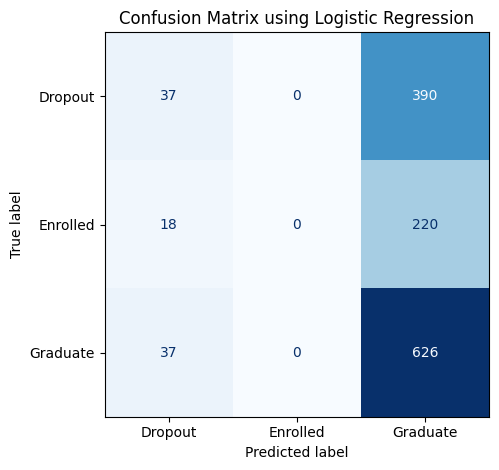

Classification results using SVM:
Test accuracy of SVM: 0.50
Computation time: 0.2095 s
              precision    recall  f1-score   support

           0       0.40      0.12      0.19       427
           1       0.00      0.00      0.00       238
           2       0.51      0.92      0.66       663

    accuracy                           0.50      1328
   macro avg       0.30      0.35      0.28      1328
weighted avg       0.38      0.50      0.39      1328



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


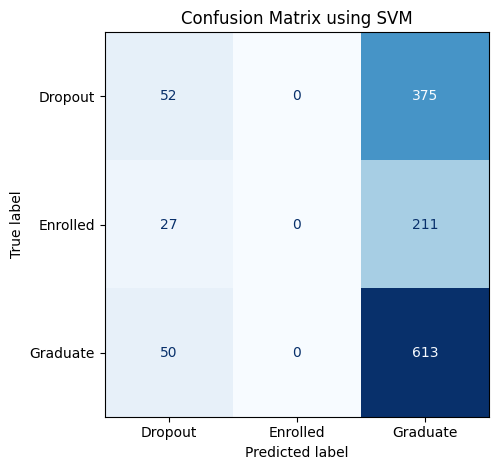

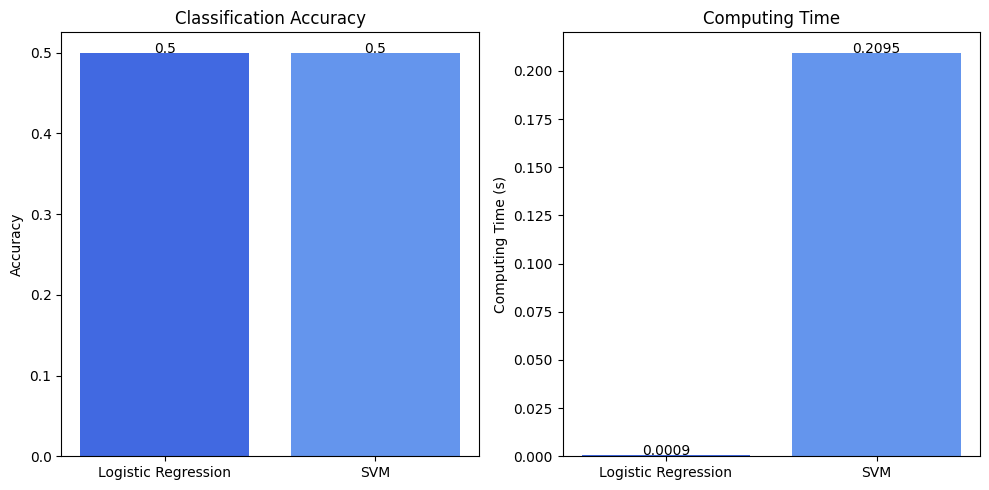

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Get the features that are not categorical, these are the features that are continuous according to the dataset variables report
X = data[["Previous qualification (grade)", "Admission grade", "Unemployment rate", "Inflation rate", "GDP"]]
y = data["Target"]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, stratify = y, random_state = 42)   # Do a 70-30 split

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components = 2)   # Perform LDA, obtain 2 components
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Encode the labels
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train.values.ravel())
y_test_encoded = encoder.fit_transform(y_test.values.ravel())

# Create scatterplot of PCA results
targets = list(np.unique(y))
colors = ["lightskyblue", "slategrey", "royalblue"]
for color, i, target_name in zip(colors, [0, 1, 2], targets):   # Plot the principal components of the training and test sets as a scatterplot
  plt.scatter(X_train_lda[y_train_encoded == i, 0], X_train_pca[y_train_encoded == i, 1], color = color, alpha = 0.8, lw = 2, label = target_name + "(Train)")
  plt.scatter(X_test_lda[y_test_encoded == i, 0], X_test_pca[y_test_encoded == i, 1], color = color, alpha = 0.8, lw = 2, label = target_name + "(Test)", marker = "x")

plt.legend(loc = "best", shadow = False)    # Add a legend
plt.title("LDA of the dataset")
plt.tight_layout()
plt.grid()
plt.show()

# Check the accuracy of LDA on training and testing data
print("========== Accuracy of LDA on training and testing data ==========")
print(f"Training accuracy: {lda.score(X_train, y_train):.2f}")
print(f"Testing accuracy: {lda.score(X_test, y_test):.2f}")

y_pred = lda.predict(X_test)
print(classification_report(y_test, y_pred))  # Print the classification report
cm = confusion_matrix(y_test, y_pred)  # Display the confusion matrix of the classification results of LDA
ConfusionMatrixDisplay(cm, display_labels = list(np.unique(y_test))).plot(cmap = plt.cm.Blues, colorbar = False)
plt.title(f"Confusion Matrix of LDA")
plt.tight_layout()
plt.show()

### Do classification on the principal components after LDA
print("========== Classification on new feature space after LDA ==========")
Classify(X_train_lda, X_test_lda, y_train, y_test)    # Use the function "Classify" from the previous section

## **Conclusions**

The following may be observed based on the results of the experiments:

* **EDA:** A majority of the features are nominal (categorical) in nature but they are, weirdly enough, those with high correlation. For example, father's occupation and mother's occupation obtained strong positive correlation (which is somewhat weird because it implies that the occupation of one parent somehow dictates that of the other). Furthermore, curricular units for the same semester also obtained high correlation scores which makes sense because the classes enrolled in a semester should be the classes approved and etc. These columns may be dropped should it be needed in classification. In terms of the balance within the number of classes within the data, it appears that class labels "Graduate" dominates over the other two: "Enrolled" and "Dropout". To rectify this class imbalance, SMOTE was applied  to balance the classes.

* **Classification without dimensionality reduction:** Although the classification results are not the best in terms of accuracy, we see from the results that SVM obtain better accuracy but with longer computation time. The opposite is true for logistic regression, which is able to classify within less than a tenth of a second but with lower accuracy scores. This could probably be from the fact that most of the columns contain categorical data. Moreover, dropping the columns with high correlation did not help in improving the performance of the classifiers. The performance actually decreased when this was done, necessitating dimensionality reduction through other methods.

* **PCA and classification results:** For PCA and LDA, we consider only the columns that contain continuous data because categorical data is not best for PCA and LDA. After some test runs, the original data without applying SMOTE obtained better results than the data with SMOTE. Obtaining only 2 principal components, the accuracy of the classification models used in the previous runs dropped to **0.50** for logistic regression and **0.51** for SVM, with SVM having a longer computation time. The same results were observed when the number of components were increased so **n=2** was set so that we may visualize a scatter plot of the principal components.

* **LDA and classification results:** Results after LDA show that using logistic regression obtained an accuracy of **0.51** while SVM obtained **0.52**. Though not a significant improvement from PCA, these results were slightly better than after PCA. The misclassifications for both PCA and LDA were mostly "Enrolled" and "Dropout" misclassified as "Graduate". This may be because there is more variation within the instances labelled as "Graduate". Using SMOTE on the data here does not really improve the classification results because SMOTE would only estimate and interpolate data from the existing ones.

* **Overall:** In terms of performance, w/o dimensionality reduction > after LDA > after PCA is the ranking. The computation times generally are the same among the three experiments with logistic regression classifying within less than tenth of a second while SVM classifying around 0.20 of a second. Generally, however, the experiments also tell us that categorical data are not as optimal in classification than continuous data, e.g. *demographics (age, gender, parents' occupation, nationality) are not really indicative of a student's academic success rate.*

In [ ]:
# Filter the features with high correlation
data = pd.concat((X, y), axis = 1)
threshold = 0.25    # Set the threshold of the correlation value, strong positive or strong negative correlation

highly_correlated_features = []   # Initialize an empty list of highly-correlated features
for i in range(len(corr_matrix.columns)):   # Iterate over each value in the correlation matrix
  for j in range(i + 1, len(corr_matrix.columns)):
    if abs(corr_matrix.iloc[i, j]) > threshold:    # Append these to the list if value is beyond the threshold
      highly_correlated_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if not highly_correlated_features:    # If there are no highly-correlated values, print this
  print("No highly-correlated features found.")

else:
  print("========== Correlated Features ==========")    # Print and plot the features with high correlation
  for feature1, feature2, correlation in highly_correlated_features:
    print(f"{feature1} and {feature2}: {correlation:.2f}")
    plt.scatter(data[feature1], data[feature2], color = "royalblue", alpha = 0.8) # Create a scatterplot of feature1 v. feature2 for visualization
    plt.xlabel(f"{feature1}")   # x-axis title
    plt.ylabel(f"{feature2}")   # y-axis title
    plt.title(f"{feature1} vs {feature2}")    # Plot title
    plt.grid()    # Insert grid
    plt.tight_layout()
    plt.show()    # Dispay the plot

# Get the features with high correlation
column_names = []   # Initialize empty list of column names of highly-correlated features
for feature1, feature2, correlation in highly_correlated_features:
  column_names.append(feature1)   # Add them to the empty list
  column_names.append(feature2)

column_names = list(set(column_names))   # Remove duplicates
print("Features with high correlation:")    # Display the list of features with high correlation
for column in column_names:
  print(column)